# Make sure to select the impact_bmad_container jupyter env in the top right corner

## Timing

In [1]:
import time
st=time.time()

### This notebook runs Lume-Impact to L0AFEND, Bmad from there.

## Import Statements

In [2]:
import numpy as np
from distgen import Generator
import impact
from impact import Impact, run_impact_with_distgen, evaluate_impact_with_distgen
from impact.autophase import autophase_and_scale
import os
from pmd_beamphysics import single_particle, ParticleGroup

import xopt

from xopt import Xopt, Evaluator
from concurrent.futures import Executor, Future, ProcessPoolExecutor

from pytao import Tao
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import re
import io
from os import path,environ
import pandas as pd
import h5py
import pmd_beamphysics
import glob
import concurrent.futures
import copy
import yaml
import pickle

import random


from pmd_beamphysics.statistics import resample_particles

%run -i helper_funcs.py

os.environ['OMP_NUM_THREADS']=str(len(os.sched_getaffinity(0))-1)
print("The jupyter kernel has access to this many threads and will use them for parallel processing. If you would like this notebook to have more threads launch it with the command line instructions found on confluence, instead of Open OnDemand.")
!echo $OMP_NUM_THREADS

The jupyter kernel has access to this many threads and will use them for parallel processing. If you would like this notebook to have more threads launch it with the command line instructions found on confluence, instead of Open OnDemand.
255


## Set Environment Variables

In [3]:

# Access environment variables
facet2_lattice = '/global/homes/o/ocamacho/impact_bmad_container_notebooks/facet2-lattice'#os.environ.get('FACET2_LATTICE', 'Not set')
scratch = os.environ.get('SCRATCH', 'Not set')

os.environ['FACET2_LATTICE'] = facet2_lattice


print(f'Make sure environment was set!:  FACET2_LATTICE={facet2_lattice}')
print(f'Make sure environment was set!:  SCRATCH={scratch}')

# Validate environment variables
!echo $FACET2_LATTICE
!echo $SCRATCH

Make sure environment was set!:  FACET2_LATTICE=/global/homes/o/ocamacho/impact_bmad_container_notebooks/facet2-lattice
Make sure environment was set!:  SCRATCH=/pscratch/sd/o/ocamacho
/global/homes/o/ocamacho/impact_bmad_container_notebooks/facet2-lattice
/pscratch/sd/o/ocamacho


## Define Inputs


In [4]:
NAME = '1.6nC_s2e_100k' #folder to be created that holds all results
FILEPATH=os.path.join(os.environ['HOME'], 'impact_bmad_container_notebooks', 'Sol_Scan_FACET') # Above folder created in this location
filename='Sol_Scan1.json' #Solenoid scan output name

GFILE = os.path.expandvars('distgen.yaml') # Distgen input file
YFILE = os.path.expandvars('ImpactT.yaml') # To be created based on template and updated for final run
YFILE_TEMPLATE = os.path.expandvars('ImpactT-template.yaml') #Initial settings

L0AF_E_Gain=62924849.46502216 # Calculated L0AF energy gain from January 2024 nominal power readbacks
L0BF_E_Gain=60473730.43463376 # Calculated L0BF energy gain from January 2024 nominal power readbacks
sim_sol_conv=1.6 #Convert from PV value to T/m (simulation input)
L0AF_Phase=0 #L0AF phase; 0 is max E phase

Bmad_Settings={}
# Define energy setpoints at exit of L0 L1 L2 in eV
Bmad_Settings['L0energy'] = 0.125e9;    
Bmad_Settings['L1energy'] = 0.338e9;
Bmad_Settings['L2energy'] = 4.5e9;

# Define L1 and L2 phases in deg
Bmad_Settings['L1phase'] = -17.0;
Bmad_Settings['L2phase'] = -41.5;

#Injector quads
Bmad_Settings['QA10361:b1_gradient'] = 2.985123	
Bmad_Settings['QA10371:b1_gradient'] = -2.824138	
Bmad_Settings['QE10425:b1_gradient'] = 5.964119	
Bmad_Settings['QE10441:b1_gradient'] = -6.215696	
Bmad_Settings['QE10511:b1_gradient'] = 2.41815	
Bmad_Settings['QE10525:b1_gradient'] = 3.240741	
Bmad_Settings['L0BF_E_Gain'] = L0BF_E_Gain
Bmad_Settings['L0BF_Phase:theta0_deg'] = -10;

#CSR for Bmad
Bmad_CSR_Command =  'csron' # 'csron' or 'csroff'

#Bmad output locations
#locations = ['L0AFEND','L0BFEND','BC11CBEG','BC11CEND',
#             'BEGBC14_1','ENDBC14_2','BEGBC20', 'CB1LE', 'CB2LE', 'CB3LE', 'CB3RE', 'CB2RE', 'CB1RE']#,'PENT']; #Bmad output locations
locations = ['BEGBC20',
             'CB1LE',
             'BEGB2LE',
             'CB2LE',
             'BEGB3LE',
             'CB3LE', 
             'BEGB3RE',
             'CB3RE',
             'BEGB2RE',
             'CB2RE', 
             'BEGB1RE',
             'CB1RE']#,'PENT']; #Bmad output locations



#Impact settings
SETTINGS0 = {
    'numprocs':(len(os.sched_getaffinity(0)))-4, #Number of available cores, minus one (jupyter is running in one core)
    'header:Nx':32,
    'header:Ny':32,  
    'header:Nz':32, 
    'stop_1:s':4.2,
    #edit
    'distgen:n_particle':5e4,
    #
    'GUNF:theta0_deg':26.8-90.5,#30 degrees-adjustment for phase def.
    'GUNF:rf_field_scale': 123/2.44885*1e6,
    'SOL10111:solenoid_field_scale':-0.41/sim_sol_conv,
    'PR10241:sample_frequency':1,
    'workdir': os.environ.get('SCRATCH', '/opt/scratch'),
    'command': '/opt/conda/bin/ImpactTexe',    
    'command_mpi': '/opt/conda/bin/ImpactTexe-mpi',
    'mpi_run':'mpiexec --map-by :OVERSUBSCRIBE -n {nproc} {command_mpi}' #todo test 
}

#Solenoid scan settings
smin=0.3
smax=0.45
sstep=0.001

filepath=FILEPATH+'/'+NAME

In [5]:
locations

['BEGBC20',
 'CB1LE',
 'BEGB2LE',
 'CB2LE',
 'BEGB3LE',
 'CB3LE',
 'BEGB3RE',
 'CB3RE',
 'BEGB2RE',
 'CB2RE',
 'BEGB1RE',
 'CB1RE']

In [6]:
l0afEndPath = '/global/homes/o/ocamacho/impact_bmad_container_notebooks/bmad_input_beams/L0AFEND.h5'

## Define Bmad function

In [31]:
def run_bmad(settings,locations,Bmad_CSR_Command, csr_file = ""):
    if(Bmad_CSR_Command == 'csroff'):
        print("Running without CSR")
    elif(Bmad_CSR_Command == 'csron'):
        print("Running with CSR");
    !echo $OMP_NUM_THREAD
    bunch={}
    
    tao=Tao('-init {:s}/bmad/models/f2_elec/tao.init -noplot'.format(facet2_lattice)) 

    #tao=Tao('-init {:s}/bmad/models/f2_elec/tao.init -noplot'.format(environ['FACET2_LATTICE'])) 
    floorplan=pd.read_csv(io.StringIO('\n'.join(tao.show('lat -all -floor_coords -tracking_elements')[3:-5])), sep="[\\s\n]+",engine='python',
            names=['Index','ElementName','ElementType','s','ds','X','Y','Z','Theta','Phi','Psi'])
    floorplan.drop(0,inplace=True);
    
    # Write CSR wakes
    if csr_file != "":
        tao.cmd( f"set space_charge_com%diagnostic_output_file = {csr_file} ");
        print(f"Saving CSR wakes at {csr_file}")
    if 'L0BF_Phase:theta0_deg' in settings.columns:
        tao.cmd('set ele {} PHI0={}'.format('L0BF', (settings['L0BF_Phase:theta0_deg'].values)/360))
    if 'L0BF_E_Gain' in settings.columns:
        tao.cmd('set ele {} VOLTAGE={}'.format('L0BF', settings['L0BF_E_Gain'].values))

    if 'QA10361:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QA10361', (settings['QA10361:b1_gradient'].values)))
    if 'QA10371:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QA10371', (settings['QA10371:b1_gradient'].values)))
    if 'QA10425:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QE10425', (settings['QE10425:b1_gradient'].values)))
    if 'QA10441:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QE10441', (settings['QE10441:b1_gradient'].values)))
    if 'QA10511:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QE10511', (settings['QE10511:b1_gradient'].values)))
    if 'QA10525:b1_gradient' in settings.columns:
        tao.cmd('set ele {} B1_GRADIENT={}'.format('QE10525', (settings['QE10525:b1_gradient'].values)))
    
    # Find element strings matching L1, L2 and L3
    #These more general match strings might cause problems by including both lords and slaves!
    L1MatchStrings = ["K11_1*", "K11_2*"]
    L2MatchStrings = ["K11_4*", "K11_5*", "K11_6*", "K11_7*", "K11_8*", "K12_*", "K13_*", "K14_*"]
    L3MatchStrings = ["K15_*", "K16_*", "K17_*", "K18_*", "K19_*"]
    
    #Therefore, use lat_list and these general search strings to get specific elements
    #Recall that, by default, lat_list has the flag "-track_only" so lords are not included
    #But some of the tracking elements are super_slaves which cannot be `set`
    
    #"-array_out" flag is on by default but if flags are edited, need to re-add manually to get numeric values back
    
    L1MatchStrings = np.concatenate( [ tao.lat_list(i,"ele.name", flags="-no_slaves") for i in L1MatchStrings ] )
    L2MatchStrings = np.concatenate( [ tao.lat_list(i,"ele.name", flags="-no_slaves") for i in L2MatchStrings ] )
    L3MatchStrings = np.concatenate( [ tao.lat_list(i,"ele.name", flags="-no_slaves") for i in L3MatchStrings ] )
    
    # Phase L1
    setLinacPhase(L1MatchStrings, settings['L1phase'].values,tao)
    setLinacGradientAuto( L1MatchStrings, settings['L1energy'].values - settings['L0energy'].values,tao )
    
    # Phase L2
    setLinacPhase(L2MatchStrings, settings['L2phase'].values,tao)
    setLinacGradientAuto( L2MatchStrings, settings['L2energy'].values - settings['L1energy'].values ,tao)
    
    tao.cmd('set beam_init position_file='+settings['startfile'].values[0])
    tao.cmd('reinit beam')
    # print('Track start: ', tao.beam()['track_start'])
    # print('Track end: ', tao.beam()['track_end'])
    tao.beam_init(0)['position_file']
    tao.cmd('call Activate_CSR.tao');
    
    tao.cmd(Bmad_CSR_Command)
    #This tracks the bunch in bmad
    tao.cmd('set global track_type = beam') 
    
    
    bunch['beta_y']=np.array([tao.bunch_params(x)['twiss_beta_y'] for x in floorplan.Index])
    bunch['beta_x']=np.array([tao.bunch_params(x)['twiss_beta_x'] for x in floorplan.Index])
    bunch['etot']=np.array([tao.bunch_params(x)['centroid_p0c']*0.511 for x in floorplan.Index])
    bunch['eta_y']=np.array([tao.bunch_params(x)['twiss_eta_y'] for x in floorplan.Index])
    bunch['eta_x']=np.array([tao.bunch_params(x)['twiss_eta_x'] for x in floorplan.Index])
    bunch['sigma_x']=np.array([tao.bunch_params(x)['sigma_11'] for x in floorplan.Index])
    bunch['sigma_y']=np.array([tao.bunch_params(x)['sigma_33'] for x in floorplan.Index])
    bunch['pc']=np.array([tao.bunch_params(x)['centroid_p0c'] for x in floorplan.Index])
    bunch['cent']=np.array([tao.bunch_params(x)['centroid_vec_1'] for x in floorplan.Index])
    bunch['sigma_11']=np.array([tao.bunch_params(x)['sigma_11'] for x in floorplan.Index])
    bunch['sigma_12']=np.array([tao.bunch_params(x)['sigma_12'] for x in floorplan.Index])
    bunch['sigma_15']=np.array([tao.bunch_params(x)['sigma_15'] for x in floorplan.Index])
    bunch['sigma_16']=np.array([tao.bunch_params(x)['sigma_16'] for x in floorplan.Index])
    
    bunch['sigma_16']=np.array([tao.bunch_params(x)['sigma_16'] for x in floorplan.Index])
    bunch['sigma_26']=np.array([tao.bunch_params(x)['sigma_26'] for x in floorplan.Index])
    bunch['sigma_56']=np.array([tao.bunch_params(x)['sigma_56'] for x in floorplan.Index])
    bunch['sigma_66']=np.array([tao.bunch_params(x)['sigma_66'] for x in floorplan.Index]) 
    
    bunch['sigma_24']=np.array([tao.bunch_params(x)['sigma_24'] for x in floorplan.Index])
    bunch['sigma_25']=np.array([tao.bunch_params(x)['sigma_25'] for x in floorplan.Index])
    bunch['sigma_26']=np.array([tao.bunch_params(x)['sigma_26'] for x in floorplan.Index])

    bunch['s']=np.array([tao.lat_list(x,'ele.s')[0] for x in floorplan.Index])
    
    #bunch['emit_y']=np.array([ ( tao.bunch_params(x)['sigma_11'] * tao.bunch_params(x)['sigma_22']- tao.bunch_params(x)['sigma21']**2 )**(1/2) for x in floorplan.Index])
    #bunch['emit_x']=np.array([ ( tao.bunch_params(x)['sigma_11'] * tao.bunch_params(x)['sigma_22']- tao.bunch_params(x)['sigma21']**2 )**(1/2) for x in floorplan.Index])
    
    
    bunch['idx']=settings['startfile'].index
    # print(settings['startfile'].index)
    P=[]
    for location in locations:
        Ptemp = ParticleGroup(data=tao.bunch_data(location))
        # Select out live particles
        print(f"Dumping beam at location {location}")
        Ptemp = Ptemp[Ptemp.status==1]
        Ptemp.drift_to_z()
        P.append(Ptemp)
    bunch['P']=P
    return bunch, tao

## Take a look at initial phase space

<>:15: SyntaxWarning: invalid escape sequence '\z'
<>:15: SyntaxWarning: invalid escape sequence '\z'
/tmp/ipykernel_1068306/3069836247.py:15: SyntaxWarning: invalid escape sequence '\z'
  plt.xlabel('$\zeta$ ($\mu m$)'); plt.ylabel('$p_z (MeV)$');


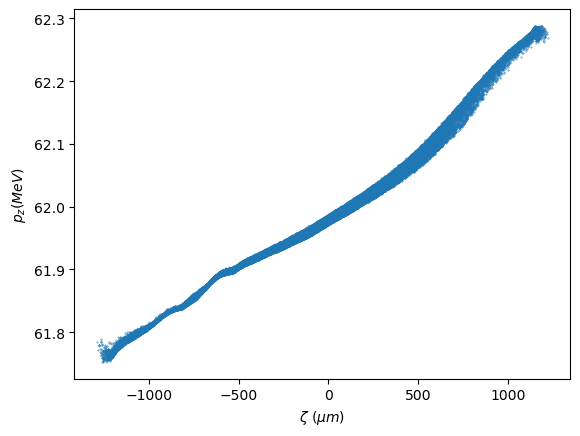

In [32]:
psDict = {};
with h5py.File(l0afEndPath, 'r') as file:
    #print(file.keys())
    #print(file['position'].keys())
    psDict['x'] = np.array(file['position']['x']);
    psDict['y'] = np.array(file['position']['y']);
    psDict['t'] = np.array(file['time'])
    
    psDict['px'] = np.array(file['momentum']['x']);
    psDict['py'] = np.array(file['momentum']['y']);
    psDict['pz'] = np.array(file['momentum']['z']);
    
p0 = np.mean(psDict['pz'])
plt.scatter( -1e6*(3e8*psDict['t']), psDict['pz']/(1e6), s = .1)
plt.xlabel('$\zeta$ ($\mu m$)'); plt.ylabel('$p_z (MeV)$');

## Prepare Bmad Settings for Run

In [33]:
tao=Tao('-init {:s}/bmad/models/f2_elec/tao.init -noplot'.format(facet2_lattice)  )
#print( ('-init {:s}/bmad/models/f2_elec/tao.init -noplot'.format(facet2_lattice)  )    )

In [34]:
Bmad_Settings=pd.DataFrame(Bmad_Settings,index=[0]).head()
Bmad_Settings['startfile']= l0afEndPath#filepath+'/L0AFEND.h5'

In [35]:
Bmad_Settings.keys()

Index(['L0energy', 'L1energy', 'L2energy', 'L1phase', 'L2phase',
       'QA10361:b1_gradient', 'QA10371:b1_gradient', 'QE10425:b1_gradient',
       'QE10441:b1_gradient', 'QE10511:b1_gradient', 'QE10525:b1_gradient',
       'L0BF_E_Gain', 'L0BF_Phase:theta0_deg', 'startfile'],
      dtype='object')

In [36]:
#print('set beam_init position_file='+Bmad_Settings['startfile'].values[0])

In [37]:
#print(Bmad_Settings['startfile'])

In [38]:
tao.show('lat -all -floor_coords -tracking_elements')[1298:];

In [15]:
#loorplan=pd.read_csv(io.StringIO('\n'.join(tao.show('lat -all -floor_coords -tracking_elements')[3:-5])), sep="[\\s\n]+",engine='python',
 #           names=['Index','ElementName','ElementType','s','ds','X','Y','Z','Theta','Phi','Psi'])
#floorplan.drop(0,inplace=True)

In [16]:
#floorplan['ElementName'][1460: 1465]

In [17]:
#floorplan['ElementName'][1373]

## Run Bmad

#### Phase Scan Grid

In [39]:
L1Vals = np.arange(-2.5, 2.50, 0.5)
L1Vals += -19.0;
L2Vals = np.arange(-2.5, 2.50, 0.5)
L2Vals += -39.5;

print("L1:", L1Vals);
print('\n')
print("L2:", L2Vals);
nTot = (len(L1Vals)*len(L1Vals))
tEst = (nTot*2/60)
print(f"{nTot} total phases to be scanned, estimated runtime {tEst:.1f} hours")

L1: [-21.5 -21.  -20.5 -20.  -19.5 -19.  -18.5 -18.  -17.5 -17. ]


L2: [-42.  -41.5 -41.  -40.5 -40.  -39.5 -39.  -38.5 -38.  -37.5]
100 total phases to be scanned, estimated runtime 3.3 hours


In [40]:
#L1Vals = np.arange(-2.5 - 0.25, 2.50 + 0.25, 0.5)
#L1Vals += -19.0;
#L2Vals = np.arange(-2.5 - 0.25, 2.50 + 0.25, 0.5)
#L2Vals += -39.5;

#print("L1:", L1Vals);
#print('\n')
#print("L2:", L2Vals);
#nTot = (len(L1Vals)*len(L1Vals))
#tEst = (nTot*2/60)
#print(f"{nTot} total phases to be scanned, estimated runtime {tEst:.1f} hours")

In [41]:
import h5py
import numpy as np
import re

def parse_text_file(filename):
    """Parse the text file and extract data for each step."""
    data = {}
    with open(filename, 'r') as file:
        lines = file.readlines()
    
    step_index = None
    for line in lines:
        if re.match(r'! Step index:', line):
            step_index = int(line.split(':')[1].strip())
            data[step_index] = {'S-position': None, 'Z': [], 'Charge/Meter': [], 'CSR_Kick/m': [], 'I_CSR/m': [], 'S_Source': []}
        elif re.match(r'! S-position:', line):
            if step_index is not None:
                data[step_index]['S-position'] = float(line.split(':')[1].strip())
        elif re.match(r'^\s*-?\d', line):
            values = list(map(float, line.split()))
            if step_index is not None:
                data[step_index]['Z'].append(values[0])
                data[step_index]['Charge/Meter'].append(values[1])
                data[step_index]['CSR_Kick/m'].append(values[2])
                data[step_index]['I_CSR/m'].append(values[3])
                data[step_index]['S_Source'].append(values[4])
    
    # Convert lists to numpy arrays
    for step in data:
        for key in data[step]:
            data[step][key] = np.array(data[step][key])
    
    return data

def write_to_h5(data, h5_filename):
    """Write the parsed data to an HDF5 file."""
    with h5py.File(h5_filename, 'w') as h5_file:
        for step, step_data in data.items():
            group = h5_file.create_group(f"Step_{step}")
            group.create_dataset('S-position', data=step_data['S-position'])
            group.create_dataset('Z', data=step_data['Z'])
            group.create_dataset('Charge_m', data=step_data['Charge/Meter'])
            group.create_dataset('CSR_Kick_m', data=step_data['CSR_Kick/m'])
            group.create_dataset('I_CSR_m', data=step_data['I_CSR/m'])
            group.create_dataset('S_Source', data=step_data['S_Source'])

def convert_text_to_h5(text_filename, h5_filename):
    """Convert the given text file to an HDF5 file."""
    data = parse_text_file(text_filename)
    write_to_h5(data, h5_filename)

In [42]:
p0Dict = {};
def run_bmad_phases(L1 = -17.0, L2 = -41.5, archive = False, base_dir = '/global/cfs/cdirs/m669/obed/w_chicane_bmad_outputs/'):
    Bmad_Settings['L1phase'] = L1;
    Bmad_Settings['L2phase'] = L2;
    label = str(L1) + '_' + str(L2);
    # Save CSR sims
    if Bmad_CSR_Command == 'csron':
        csr_txt_file = base_dir + '/bmad' + 'csr' + '_' + label + '.txt';
    else:
        csr_txt_file = "";
    bmad_results, tao =run_bmad(Bmad_Settings,locations,Bmad_CSR_Command, csr_txt_file);
    csr_h5_file =  base_dir + '/bmad' + 'csr' + '_' + label + '.h5';
    data = parse_text_file(csr_txt_file)
    write_to_h5(data, csr_h5_file)
    # What if we leave the original txt?
    #os.remove(csr_txt_file)
    if archive:
        # Save beam
        file_loc = base_dir +'/bmad_' + Bmad_CSR_Command + '_' + label + '.pkl';
        output = open(file_loc, 'wb')
        pickle.dump(bmad_results,output)
        print(f"Saved sim at {file_loc}")
        output.close()
    
    et=time.time()
    elapsed_time=et-st
    print('Execution time:', elapsed_time, 'seconds')

    return bmad_results;

# Run single sim

In [43]:
bunch  = run_bmad_phases(-17.0, -41.5, True)

Running with CSR

Saving CSR wakes at /global/cfs/cdirs/m669/obed/w_chicane_bmad_outputs//bmadcsr_-17.0_-41.5.txt
Dumping beam at location BEGBC20
Dumping beam at location CB1LE
Dumping beam at location BEGB2LE
Dumping beam at location CB2LE
Dumping beam at location BEGB3LE
Dumping beam at location CB3LE
Dumping beam at location BEGB3RE
Dumping beam at location CB3RE
Dumping beam at location BEGB2RE
Dumping beam at location CB2RE
Dumping beam at location BEGB1RE
Dumping beam at location CB1RE
Saved sim at /global/cfs/cdirs/m669/obed/w_chicane_bmad_outputs//bmad_csron_-17.0_-41.5.pkl
Execution time: 18190.936908721924 seconds


## Check Timing

In [26]:
et=time.time()
elapsed_time=et-st

print('Execution time:', elapsed_time, 'seconds')

Execution time: 17513.29833316803 seconds


## Upsampling Attempt

In [27]:
workDir = r'/global/homes/o/ocamacho/impact_bmad_container_notebooks/Sol_Scan_FACET/1.6nC_s2e_100k/';

In [29]:
import numpy as np
from sklearn.neighbors import KernelDensity
import pickle
import matplotlib.pyplot as plt;
import os

def upSample(workDir, particles, outfile, N):
    # Original data
    np.random.seed(0)
    n_samples = 100000
    n_features = 6
    path = workDir + filename;
    
    

    f = particles
    deltaT = f['delta_t']; deltaT -= np.mean(deltaT);
    # -beta * c*t is the bmad convention for the longitudinal coord
    # beta * c*t is the pydf convension
    zc = 299792458 * deltaT;
    pz = f['pz']; p0 = np.mean(pz);
    # Relative energy offsets
    deltaArr = pz/p0; deltaArr -= np.mean(deltaArr);
        
    xc = f['x']; xc -= np.mean(xc);
    print(np.std(xc))
    xpc = f['px']/p0; xpc -= np.mean(xpc);
        
    yc = f['y']; yc -= np.mean(xc);
    ypc = f['py']/p0; ypc -= np.mean(ypc);
        
    # Normalization factors to improve conditioning
    X = np.array([1e6*xc[0:n_samples], 1e6*xpc[0:n_samples], 1e6*yc[0:n_samples], 
                      1e6*ypc[0:n_samples], 1e6*zc[0:n_samples], 10000*deltaArr[0:n_samples]]).T#, yc[0:1000], pyc[0:1000], zc[0:1000], deltaArr[0:1000]]).T
        
    # Construct KDE model
    bandwidth = 0.1 # adjust as needed
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')

    # Fit the KDE model to the data
    kde.fit(X);


    # Generate new samples from the KDE model
    new_samples = kde.sample(n_samples= int(N), random_state=0);



    # Remove normalization factors
    XUS = new_samples.T
    XUS[0] /= 1e6
    XUS[1] /= 1e6
    XUS[2] /= 1e6
    XUS[3] /= 1e6
    XUS[4] /= 1e6
    XUS[-1] /= 1e5

    # Open an HDF5 file for writing
    with h5py.File(outfile, 'w') as h5file:
        # Phase space
        h5file.create_dataset('x', data=XUS[0])
        h5file.create_dataset('xp', data=XUS[1])
        h5file.create_dataset('y', data=XUS[2])
        h5file.create_dataset('yp', data=XUS[3])
        h5file.create_dataset('zeta', data=XUS[4])
        h5file.create_dataset('delta', data=XUS[5])
        
        # Charge and energy
        h5file.create_dataset('charge', data=-1.60e-9)
        h5file.create_dataset('energy', data=p0)
  
    #Remove normalization factors
    #XUS = new_samples.T;
    #XUS[0] /= 1e6; XUS[1] /= 1e6; XUS[2] /= 1e6; XUS[3] /= 1e6; XUS[4] /= 1e6;
    #XUS[-1] /= 1e5;
    #plt.scatter(1e6*XUS[4], XUS[5], s = 0.10)
    #np.savetxt( outfile, np.array([ XUS[0],  XUS[1],
    #            XUS[2],  XUS[3],
    #            XUS[4],  XUS[5]]).T
    #            )
    print(f"Data written to {outfile}")
        
    return;

# Batch run

In [30]:
L1Vals[8:]

array([-17.5, -17. ])

In [ ]:
%%time

#bmad_results_arr = [];
#print(f"Running {len(L1Vals)*len(L2Vals)} simulations total");
for phi1 in L1Vals:
    for phi2 in L2Vals:
        print(phi1, phi2);
        # Run bmad sim with these phases
        bmad_results = run_bmad_phases(phi1, phi2, True);
        # Phases and central energy in label
        particles_0 = bmad_results['P'][0];
        outPath = r'/global/homes/o/ocamacho/pydfCSR_sims/beam_files/BEGBC20_1M_' +  str(phi1) + '_' + str(phi2) + '_pg_.h5';
        # Upsample to a million and save txt to outPath
        upSample(workDir, particles_0, outPath, int(1e6));
        
        # Phases and central energy in label
        #particles_1 = bmad_results['P'][3];
        #outPath = r'/global/homes/o/ocamacho/pydfCSR_sims/beam_files/CB2LE_1M_' +  str(phi1) + '_' + str(phi2) + '_pg_.h5';
        # Upsample to a million and save txt to outPath
        #upSample(workDir, particles_1, outPath, int(1e6));
        
        
        #plt.hist(particles[-2], 100);
        #bmad_results_arr.append(run_bmad_phases(phi1, phi2));
        
for phi1 in L1Vals[8:]:
    for phi2 in L2Vals:
        print(phi1, phi2);
        # Run bmad sim with these phases
        bmad_results = run_bmad_phases(phi1, phi2, True);
        # Phases and central energy in label
        particles_0 = bmad_results['P'][0];
        outPath = r'/global/homes/o/ocamacho/pydfCSR_sims/beam_files/BEGBC20_1M_' +  str(phi1) + '_' + str(phi2) + '_pg_.h5';
        # Upsample to a million and save txt to outPath
        upSample(workDir, particles_0, outPath, int(1e6));
        
        # Phases and central energy in label
        #particles_1 = bmad_results['P'][3];
        #outPath = r'/global/homes/o/ocamacho/pydfCSR_sims/beam_files/CB2LE_1M_' +  str(phi1) + '_' + str(phi2) + '_pg_.h5';
        # Upsample to a million and save txt to outPath
        #upSample(workDir, particles_1, outPath, int(1e6));
        
        
        #plt.hist(particles[-2], 100);
        #bmad_results_arr.append(run_bmad_phases(phi1, phi2));

In [ ]:
plt.hist(bmad_results['P'][0].t, 100);

In [ ]:
# Write data to HDF5 file
hdf5_file = r'/global/homes/o/ocamacho/pyDFCSR/pyDFCSR_2D/example/input/BEGBC20_1M.h5';
with h5py.File(hdf5_file, 'w') as hf:
    hf.create_dataset('x', data= XUS[0]/(1e6) );
    hf.create_dataset('px', data= XUS[1]/(1e6));
    hf.create_dataset('y', data= XUS[2]/(1e6));
    hf.create_dataset('py', data= XUS[3]/(1e6));
    hf.create_dataset('z', data= XUS[4]/1e6);
    hf.create_dataset('pz', data= XUS[5]/1e5);
    
print(f"Data written to {hdf5_file}.");

In [ ]:
txt_file = r'/global/homes/o/ocamacho/pyDFCSR/pyDFCSR_2D/example/input/BEGBC20_1M.txt';
np.savetxt( txt_file, np.array([ XUS[0]/(1e6),  XUS[1]/(1e6),
           XUS[2]/(1e6),  XUS[3]/(1e6),
           XUS[4]/(1e6),  XUS[5]/(1e5)]).T
          );
print(f"Data written to {txt_file}");

In [ ]:
data = np.loadtxt(txt_file);

In [ ]:
np.shape(data);

In [ ]:
print( np.shape(X) );

X1 = np.random.randn(100, 2);

np.shape(X1);

In [ ]:
# Gaussian Mixture Model

In [ ]:
%%time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


# Create an instance of GaussianMixture
gmm = GaussianMixture(n_components= 200, random_state=1)  # Specify number of components

# Fit the model to the data
gmm.fit(X[0:50000, :])

In [ ]:
n_samples = 9e5
X_samples, _ = gmm.sample(n_samples)


#XUS = new_samples.T;
#print(len(XUS[0]))
#print(len(xc[0:n_samples]))
fig, ax = plt.subplots(1, 2, figsize = (8,4))
ind0 = 4; ind1 = 5;
arr00 = X_samples.T[ind0]; arr01 = X_samples.T[ind1]
ax[0].scatter(arr00, arr01, s = .1, c = 'salmon')
arr10 = X.T[ind0][0:50000]; arr11 = X.T[ind1][0:50000]
ax[1].scatter(arr10, arr11, s = .1, c= 'salmon')

#for elem in ax:
#    elem.set_ylim(-35, 35);
#    elem.set_xlim(-350, 350);


In [ ]:
import os

os.getcwd()

In [ ]:
plt.imshow( np.random.normal((1,1), .1, (10,2)) )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Define the number of bins and the range for each axis
nbins = 30
xedges = np.linspace(-3, 3, nbins)  # Adjust the range as per your data
yedges = np.linspace(-3, 3, nbins)  # Adjust the range as per your data
xpos, ypos = np.meshgrid(xedges[:-1] + 0.5 * (xedges[1] - xedges[0]), yedges[:-1] + 0.5 * (yedges[1] - yedges[0]))

# Number of frames to generate
num_frames = 30
filenames = []

# Loop to generate each frame
for i in range(num_frames):
    # Generate new data for each frame
    data = np.random.normal((i/2,i/2), 1/(1+ i), (1000, 2))  # Example: random data
    # Alternatively, you can load different datasets here
    
    # Calculate the 2D histogram
    hist, _, _ = np.histogram2d(data[:, 0], data[:, 1], bins=(xedges, yedges))
    
    # Plot the histogram
    plt.figure(figsize=(6, 6))
    plt.pcolormesh(xpos, ypos, hist.T)
    plt.colorbar()
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.title(f'2D Histogram - Frame {i+1}')

    # Save the frame as a PNG file
    filename = f'histogram_frame_{i+1}.png'
    plt.savefig(filename)
    plt.close()

    filenames.append(filename)

# Create the animated GIF
with imageio.get_writer('histogram_animation.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)


In [ ]:
import imageio

# List of filenames of the frames
filenames = ['histogram_frame_1.png', 'histogram_frame_2.png', 'histogram_frame_3.png']  # Add all your frame filenames here

# Create the animated GIF
with imageio.get_writer('histogram_animation.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)


## Remove copied files


In [ ]:
!rm -rf ImpactT_template.in
!rm -rf rfdata201
!rm -rf rfdata102
!rm -rf rfdata4
!rm -rf rfdata5
!rm -rf rfdata6
!rm -rf rfdata7
!rm -rf ImpactT.yaml